<a href="https://colab.research.google.com/github/beshoynashaat/gold-price-prediction-regression/blob/main/gold_price_prediction_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score, mean_squared_error
from sklearn.model_selection import train_test_split

In [ ]:
df=pd.read_csv("/content/annual_gold_rate.csv")

df=df.dropna().reset_index(drop=True)
df.head()

,Date,USD,EUR,GBP,INR,AED,CNY
0,1985-12-31,317.30,394.08922,246.28501,3887.39270,1162.19778,926.64518
1,1986-12-31,367.85,351.34774,251.12483,4625.06990,1351.92474,1272.38854
2,1987-12-31,446.22,366.06607,272.49236,5761.91787,1641.52338,1659.60015
3,1988-12-30,436.86,352.12732,245.62804,6039.39391,1603.97099,1626.12034
4,1989-12-29,380.82,325.48985,232.74627,6148.71301,1399.80516,1434.30585


In [ ]:
date_candidates = [c for c in df.columns if 'date' in c.lower()]
price_candidates = [c for c in df.columns if any(x in c.lower() for x in ['usd','eur','gbp','inr','aed','cny','price','rate','value'])]

print('Date candidates:', date_candidates)
print('Price candidates:', price_candidates)

# Set the date column (default to first date-like column or 'Date')
if date_candidates:
    date_col = date_candidates[0]
else:
    date_col = 'Date'  # change if necessary

# Pick a price column. Change this to 'USD' or 'EUR' if you prefer.
# By default we will use the first detected currency column. If none detected, use last column.
price_col = price_candidates[0] if price_candidates else df.columns[-1]

print(f"Using date column: {date_col}, using price column: {price_col}")

Date candidates: ['Date']
Price candidates: ['USD', 'EUR', 'GBP', 'INR', 'AED', 'CNY']
Using date column: Date, using price column: USD


In [ ]:
df[date_col]=pd.to_datetime(df[date_col], errors="coerce")
df[price_col] = pd.to_numeric(df[price_col], errors='coerce')


df = df.sort_values(by="Date").reset_index(drop=True)

df = df.rename(columns={date_col: 'Date', price_col: 'Price'})

print('Cleaned dataset sample:')
df.head()
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

df = df.dropna(subset=['Date']).copy()

df['Year'] = df['Date'].dt.year

df_yearly = df.groupby('Year').mean(numeric_only=True).reset_index()

df_yearly.head()

Cleaned dataset sample:


,Year,Price,EUR,GBP,INR,AED,CNY
0,1985,317.30,394.08922,246.28501,3887.39270,1162.19778,926.64518
1,1986,367.85,351.34774,251.12483,4625.06990,1351.92474,1272.38854
2,1987,446.22,366.06607,272.49236,5761.91787,1641.52338,1659.60015
3,1988,436.86,352.12732,245.62804,6039.39391,1603.97099,1626.12034
4,1989,380.82,325.48985,232.74627,6148.71301,1399.80516,1434.30585


In [ ]:
df['Year'] = df['Date'].dt.year

best_lag = None
best_window = None
best_error = float('inf')

lags = [1, 2, 3, 5, 7]
windows = [3, 7, 14]

for lag in lags:
    for w in windows:
        df_temp = df.copy()

        df_temp['Lag'] = df_temp['Price'].shift(lag)
        df_temp['Rolling'] = df_temp['Price'].rolling(w).mean().shift(1)

        df_temp = df_temp.dropna()

        X = df_temp[['Lag', 'Rolling']]
        y = df_temp['Price']

        split = int(len(df_temp) * 0.8)
        X_train, X_test = X[:split], X[split:]
        y_train, y_test = y[:split], y[split:]

        model = LinearRegression()
        model.fit(X_train, y_train)

        preds = model.predict(X_test)
        error = mean_squared_error(y_test, preds)

        if error < best_error:
            best_error = error
            best_lag = lag
            best_window = w

print("Best Lag:", best_lag)
print("Best Rolling Window:", best_window)
print("Error:", best_error)


df = df.dropna().reset_index(drop=True)

df.head()


Best Lag: 1
Best Rolling Window: 3
Error: 32710.092754838563


,Date,Price,EUR,GBP,INR,AED,CNY,Year
0,1985-12-31,317.30,394.08922,246.28501,3887.39270,1162.19778,926.64518,1985
1,1986-12-31,367.85,351.34774,251.12483,4625.06990,1351.92474,1272.38854,1986
2,1987-12-31,446.22,366.06607,272.49236,5761.91787,1641.52338,1659.60015,1987
3,1988-12-30,436.86,352.12732,245.62804,6039.39391,1603.97099,1626.12034,1988
4,1989-12-29,380.82,325.48985,232.74627,6148.71301,1399.80516,1434.30585,1989



Price statistics:
count      38.000000
mean      776.813947
std       529.651403
min       271.040000
25%       362.525000
50%       440.655000
75%      1255.562500
max      1800.090000
Name: Price, dtype: float64


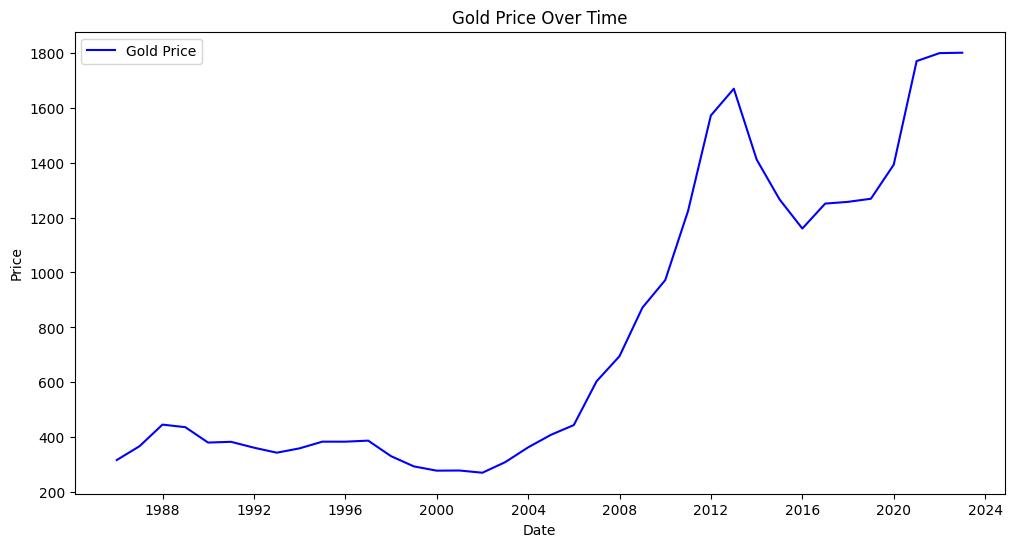

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Price'], label='Gold Price', color='blue')
plt.title('Gold Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()

print('\nPrice statistics:')
print(df_yearly['Price'].describe())

In [ ]:
split_fraction = 0.8

df_temp = df.copy()
df_temp['Lag_Feature'] = df_temp['Price'].shift(best_lag)
df_temp['Rolling_Feature'] = df_temp['Price'].rolling(best_window).mean().shift(1)

df_temp = df_temp.dropna(subset=['Lag_Feature', 'Rolling_Feature']).reset_index(drop=True)

split_idx_new = int(len(df_temp) * split_fraction)

train = df_temp.iloc[:split_idx_new].copy()
test = df_temp.iloc[split_idx_new:].copy()

print(f"Train rows: {len(train)}, Test rows: {len(test)}")

feature_cols = ['Lag_Feature', 'Rolling_Feature', 'Year']
X_train = train[feature_cols]
y_train = train['Price']
X_test = test[feature_cols]
y_test = test['Price']

print('X_train shape:', X_train.shape)

Train rows: 28, Test rows: 7
X_train shape: (28, 3)


In [ ]:
# Initialize models
lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=100, random_state=42)

# Fit models to training data
lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

# Make predictions on the test set
pred_lr = lr.predict(X_test)
pred_rf = rf.predict(X_test)

In [ ]:
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}

metrics_lr = evaluate(y_test, pred_lr)
metrics_rf = evaluate(y_test, pred_rf)

print('Linear Regression metrics:')
for k,v in metrics_lr.items():
    print(f'  {k}: {v:.4f}')

print('\nRandom Forest metrics:')
for k,v in metrics_rf.items():
    print(f'  {k}: {v:.4f}')

Linear Regression metrics:
  MAE: 109.3752
  RMSE: 150.5798
  R2: 0.6376

Random Forest metrics:
  MAE: 230.1278
  RMSE: 304.8481
  R2: -0.4855


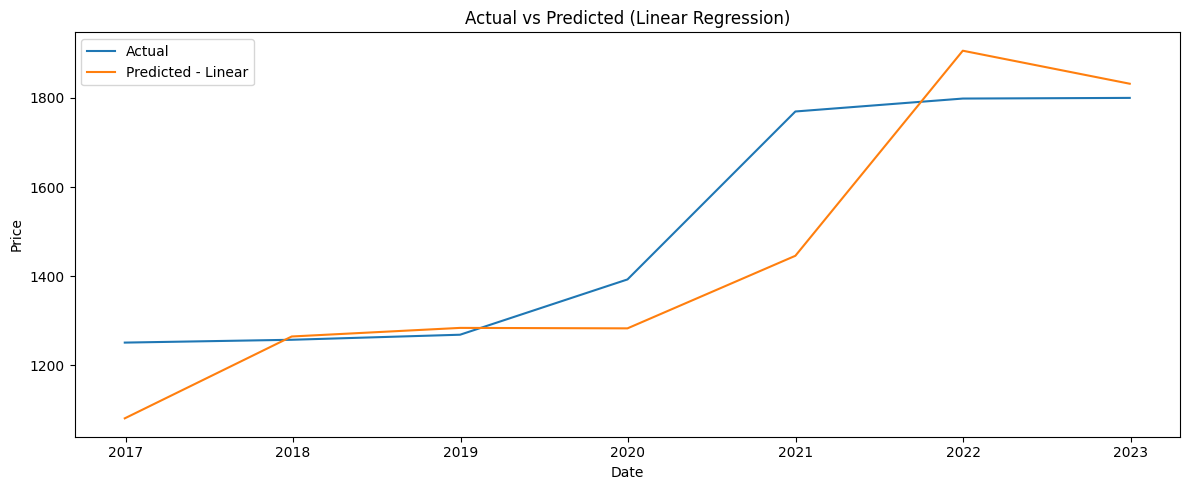

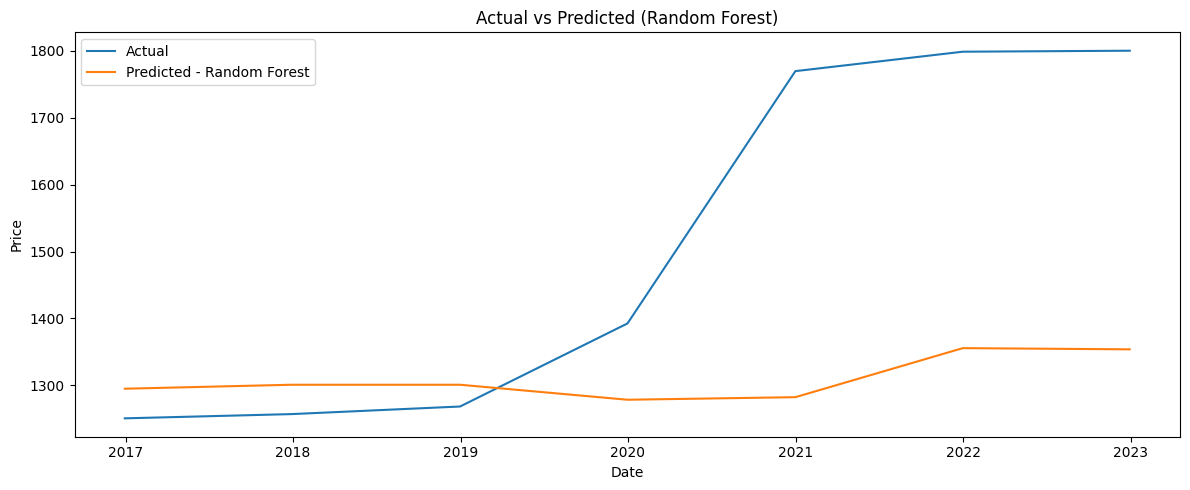

In [ ]:
# Use test dates for x-axis
dates_test = test['Date'].reset_index(drop=True)

plt.figure(figsize=(12,5))
plt.plot(dates_test, y_test.reset_index(drop=True), label='Actual')
plt.plot(dates_test, pred_lr, label='Predicted - Linear')
plt.title('Actual vs Predicted (Linear Regression)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(dates_test, y_test.reset_index(drop=True), label='Actual')
plt.plot(dates_test, pred_rf, label='Predicted - Random Forest')
plt.title('Actual vs Predicted (Random Forest)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

rf = RandomForestRegressor(random_state=42)

search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    n_jobs=-1,
    scoring='neg_mean_squared_error',
    random_state=42,
    error_score='raise'
)

search.fit(X_train, y_train)

best_rf = search.best_estimator_
pred_best_rf = best_rf.predict(X_test)


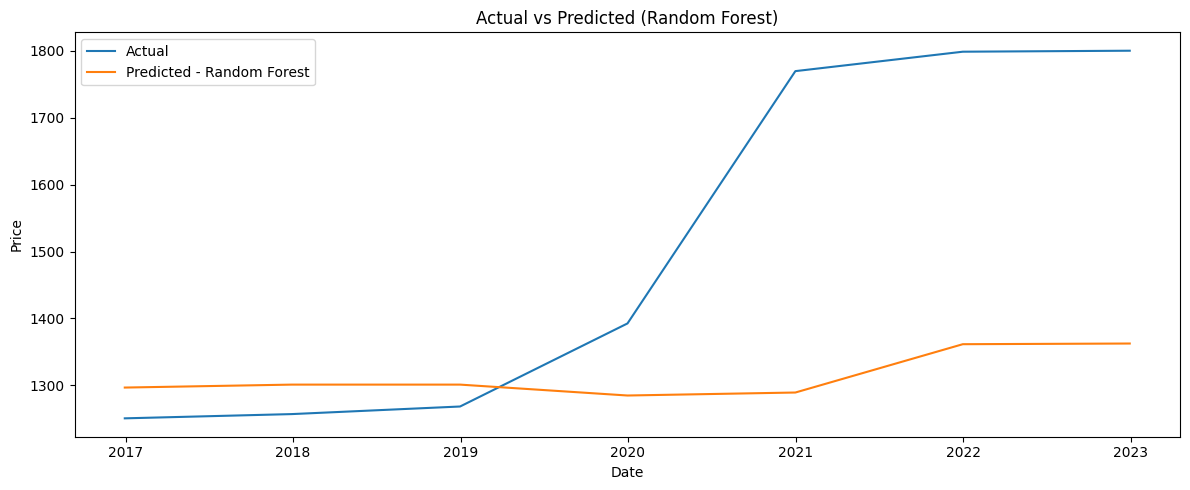

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(dates_test, y_test.reset_index(drop=True), label='Actual')
plt.plot(dates_test, pred_best_rf, label='Predicted - Random Forest')
plt.title('Actual vs Predicted (Random Forest)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()